# Telecom Customer Churn — Predictive Modelling

## Objective

The objective of this phase is to develop and evaluate a classification model
that predicts whether a telecom customer is likely to churn based on available
customer characteristics and usage behaviour.

The modelling process will include:

1. Feature and target selection
2. Training and test data preparation
3. Baseline model development
4. Model training
5. Model evaluation
6. Comparison of predictive performance
7. Business interpretation of the results

In [10]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [11]:
import os

os.listdir("../data/raw")


['Customer Churn.csv']

In [15]:
df = pd.read_csv("../data/raw/Customer Churn.csv")

In [16]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [17]:
df.shape

(3150, 14)

In [18]:
df.columns.tolist()

['Call  Failure',
 'Complains',
 'Subscription  Length',
 'Charge  Amount',
 'Seconds of Use',
 'Frequency of use',
 'Frequency of SMS',
 'Distinct Called Numbers',
 'Age Group',
 'Tariff Plan',
 'Status',
 'Age',
 'Customer Value',
 'Churn']

## 2. Feature and Target Selection

The target variable is `Churn`, where 0 represents non-churn and 1 represents churn.

Predictor variables were selected from customer characteristics, account information,
and usage behaviour available during the observation period.

`Age Group` was excluded because the dataset contains the underlying `Age` variable,
making the grouped variable redundant.

`Status` and `Customer Value` were retained for the initial baseline model because
the dataset documentation indicates that predictor variables were collected during
the first nine months, while churn was determined at the end of month 12.

In [23]:
[col for col in features if col not in df.columns]

['call_failure',
 'complains',
 'subscription_length',
 'charge_amount',
 'seconds_of_use',
 'frequency_of_use',
 'frequency_of_sms',
 'distinct_called_numbers',
 'tariff_plan',
 'status',
 'age',
 'customer_value']

In [24]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

df.columns.tolist()

['call_failure',
 'complains',
 'subscription_length',
 'charge_amount',
 'seconds_of_use',
 'frequency_of_use',
 'frequency_of_sms',
 'distinct_called_numbers',
 'age_group',
 'tariff_plan',
 'status',
 'age',
 'customer_value',
 'churn']

In [25]:
features = [
    "call_failure",
    "complains",
    "subscription_length",
    "charge_amount",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "tariff_plan",
    "status",
    "age",
    "customer_value"
]

X = df[features]
y = df["churn"]

In [26]:
X.shape, y.shape

((3150, 12), (3150,))

In [27]:
X.head()

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,tariff_plan,status,age,customer_value
0,8,0,38,0,4370,71,5,17,1,1,30,197.640
1,0,0,39,0,318,5,7,4,1,2,25,46.035
2,10,0,37,0,2453,60,359,24,1,1,30,1536.520
3,10,0,38,0,4198,66,1,35,1,1,15,240.020
4,3,0,38,0,2393,58,2,33,1,1,15,145.805


In [28]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: churn, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2520, 12), (630, 12), (2520,), (630,))

In [32]:
y.value_counts(normalize=True)

churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

In [33]:
y_train.value_counts(normalize=True)

churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

In [34]:
y_test.value_counts(normalize=True)

churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

## 3. Baseline Logistic Regression Model

A logistic regression model is used as the initial classification model.

Feature standardization is incorporated within a scikit-learn pipeline to ensure
that scaling parameters are learned only from the training data, reducing the
risk of data leakage.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [36]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [37]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['call_failure','complains','subscription_length',...,'status','age', 'customer_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [38]:
y_pred = logistic_pipeline.predict(X_test)

In [39]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [40]:
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

comparison.head(20)

,actual,predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,1,0
6,0,0
7,0,0
8,0,0
9,0,0


In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[523,   8],
       [ 57,  42]])

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [44]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.897
Precision: 0.840
Recall:    0.424
F1-score:  0.564


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       531
           1       0.84      0.42      0.56        99

    accuracy                           0.90       630
   macro avg       0.87      0.70      0.75       630
weighted avg       0.89      0.90      0.88       630



### Baseline Logistic Regression Interpretation

The baseline logistic regression model achieved approximately 90% overall accuracy.
However, class-level performance shows an important imbalance.

For the churn class (1), precision was 0.84, indicating that 84% of customers
predicted to churn were actual churners. Recall was considerably lower at 0.42,
meaning that the model identified only 42% of all actual churners. Consequently,
the churn-class F1-score was 0.56.

The model performed substantially better at identifying non-churn customers,
with recall of 0.98 and an F1-score of 0.94.

Therefore, although overall accuracy is high, the model currently misses a
substantial proportion of actual churners. This demonstrates why accuracy alone
is insufficient for evaluating performance on an imbalanced churn dataset.

In [46]:
balanced_logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

In [47]:
balanced_logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['call_failure','complains','subscription_length',...,'status','age', 'customer_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [48]:
y_pred_balanced = balanced_logistic_pipeline.predict(X_test)

In [49]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90       531
           1       0.50      0.86      0.63        99

    accuracy                           0.84       630
   macro avg       0.73      0.85      0.76       630
weighted avg       0.90      0.84      0.86       630



In [50]:
confusion_matrix(y_test, y_pred_balanced)

array([[445,  86],
       [ 14,  85]])

### Class-Weighted Logistic Regression Interpretation

Applying `class_weight="balanced"` substantially changed the model's classification
behaviour.

Churn recall increased from 0.42 to 0.86, reducing the number of missed churners
(false negatives) from 57 to 14. However, churn precision decreased from 0.84
to 0.50 as false-positive predictions increased from 8 to 86.

The churn-class F1-score improved from 0.56 to 0.63, while overall accuracy
decreased from approximately 0.90 to 0.84.

The results demonstrate the precision-recall trade-off. The balanced model is
considerably more effective at identifying actual churners, but this improvement
comes at the cost of substantially more false churn alerts. The preferred model
therefore depends on the business cost of missing a churner relative to the cost
of incorrectly targeting a non-churn customer.

In [51]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [52]:
y_prob[:20]

array([1.23244793e-01, 8.77800850e-04, 2.60280301e-02, 5.58411981e-03,
       2.77104464e-03, 3.56803983e-01, 2.48899363e-02, 2.22921549e-02,
       1.38810590e-02, 1.81772754e-01, 2.81175616e-01, 1.93354287e-01,
       2.06021627e-03, 1.41792742e-02, 3.69687980e-03, 3.40602453e-03,
       4.90352057e-03, 7.18495078e-02, 9.90039923e-01, 1.83837605e-02])

In [53]:
probability_comparison = pd.DataFrame({
    "actual": y_test.values,
    "churn_probability": y_prob,
    "prediction_0.50": y_pred
})

probability_comparison.head(20)

,actual,churn_probability,prediction_0.50
0,0,0.123245,0
1,0,0.000878,0
2,0,0.026028,0
3,0,0.005584,0
4,0,0.002771,0
5,1,0.356804,0
6,0,0.024890,0
7,0,0.022292,0
8,0,0.013881,0
9,0,0.181773,0


In [54]:
threshold = 0.30

y_pred_030 = (y_prob >= threshold).astype(int)

In [55]:
print(classification_report(y_test, y_pred_030))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       531
           1       0.63      0.77      0.69        99

    accuracy                           0.89       630
   macro avg       0.79      0.84      0.81       630
weighted avg       0.90      0.89      0.90       630



In [56]:
confusion_matrix(y_test, y_pred_030)

array([[486,  45],
       [ 23,  76]])

In [57]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [58]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    print(
        f"Fold {fold}: "
        f"Training = {len(train_idx)}, "
        f"Validation = {len(val_idx)}"
    )

Fold 1: Training = 2016, Validation = 504
Fold 2: Training = 2016, Validation = 504
Fold 3: Training = 2016, Validation = 504
Fold 4: Training = 2016, Validation = 504
Fold 5: Training = 2016, Validation = 504


In [59]:
from sklearn.model_selection import cross_val_score

In [60]:
original_f1_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

original_f1_scores

array([0.63157895, 0.55737705, 0.44094488, 0.54700855, 0.61290323])

In [61]:
print("Original Logistic Regression")
print("Fold F1 scores:", original_f1_scores)
print("Mean F1:", original_f1_scores.mean())
print("Std F1:", original_f1_scores.std())

Original Logistic Regression
Fold F1 scores: [0.63157895 0.55737705 0.44094488 0.54700855 0.61290323]
Mean F1: 0.5579625302507023
Std F1: 0.06671029824888647


In [62]:
balanced_f1_scores = cross_val_score(
    balanced_logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

balanced_f1_scores

array([0.66666667, 0.64220183, 0.65217391, 0.63302752, 0.65116279])

In [63]:
print("Balanced Logistic Regression")
print("Fold F1 scores:", balanced_f1_scores)
print("Mean F1:", balanced_f1_scores.mean())
print("Std F1:", balanced_f1_scores.std())

Balanced Logistic Regression
Fold F1 scores: [0.66666667 0.64220183 0.65217391 0.63302752 0.65116279]
Mean F1: 0.649046545641197
Std F1: 0.011208806707605996


### Cross-Validation Comparison

Five-fold stratified cross-validation was used to compare the original and
class-weighted logistic regression models using churn-class F1-score.

The original logistic regression achieved a mean F1-score of approximately
0.558 with a standard deviation of 0.067.

The class-weighted logistic regression achieved a higher mean F1-score of
approximately 0.649 and a substantially lower standard deviation of 0.012.

These results indicate that the class-weighted logistic regression provides
both stronger and more consistent churn-class performance across the validation
folds. It is therefore preferred to the original logistic regression at this
stage of model development.

In [64]:
from sklearn.tree import DecisionTreeClassifier

In [65]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

In [66]:
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [67]:
y_train_pred_tree = decision_tree.predict(X_train)

print(classification_report(y_train, y_train_pred_tree))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2124
           1       0.95      1.00      0.97       396

    accuracy                           0.99      2520
   macro avg       0.97      0.99      0.98      2520
weighted avg       0.99      0.99      0.99      2520



In [68]:
tree_f1_scores = cross_val_score(
    decision_tree,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

tree_f1_scores

array([0.81818182, 0.80519481, 0.81212121, 0.77987421, 0.83544304])

In [69]:
print("Unrestricted Decision Tree")
print("Fold F1 scores:", tree_f1_scores)
print("Mean F1:", tree_f1_scores.mean())
print("Std F1:", tree_f1_scores.std())

Unrestricted Decision Tree
Fold F1 scores: [0.81818182 0.80519481 0.81212121 0.77987421 0.83544304]
Mean F1: 0.8101630174617995
Std F1: 0.01816210277818382


In [70]:
print("Tree depth:", decision_tree.get_depth())
print("Number of leaves:", decision_tree.get_n_leaves())

Tree depth: 19
Number of leaves: 151


In [71]:
depth_results = []

for depth in range(2, 16):
    tree = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )
    
    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )
    
    depth_results.append({
        "max_depth": depth,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,max_depth,mean_f1,std_f1
0,2,0.650968,0.021961
1,3,0.639238,0.024715
2,4,0.690105,0.015673
3,5,0.670173,0.021136
4,6,0.685611,0.020038
5,7,0.691634,0.020832
6,8,0.730040,0.025207
7,9,0.768985,0.034929
8,10,0.793378,0.024683
9,11,0.792273,0.032534


In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
tree_for_tuning = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

In [74]:
param_grid = {
    "max_depth": [8, 10, 12, 14],
    "min_samples_leaf": [1, 5, 10, 20]
}

In [75]:
grid_search = GridSearchCV(
    estimator=tree_for_tuning,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

In [76]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [8, 10, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls 

In [77]:
print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best parameters: {'max_depth': 14, 'min_samples_leaf': 1}
Best CV F1: 0.8053768257739267


In [78]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[
    [
        "param_max_depth",
        "param_min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score,rank_test_score
12,14,1,0.805377,0.021961,1
8,12,1,0.800520,0.018507,2
4,10,1,0.793378,0.024683,3
5,10,5,0.783764,0.027782,4
13,14,5,0.778331,0.016957,5
9,12,5,0.774866,0.016410,6
6,10,10,0.754925,0.036332,7
14,14,10,0.751057,0.031532,8
10,12,10,0.750465,0.032154,9
1,8,5,0.732219,0.018044,10


In [79]:
param_grid_refined = {
    "max_depth": [10, 12, 14, 16, None],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 5, 10]
}

In [80]:
refined_grid_search = GridSearchCV(
    estimator=tree_for_tuning,
    param_grid=param_grid_refined,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

In [81]:
refined_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 12, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [82]:
print("Best parameters:", refined_grid_search.best_params_)
print("Best CV F1:", refined_grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.8101630174617995


In [83]:
refined_results = pd.DataFrame(refined_grid_search.cv_results_)

refined_results[
    [
        "param_max_depth",
        "param_min_samples_leaf",
        "param_min_samples_split",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_score,std_test_score,rank_test_score
36,None,1,2,0.810163,0.018162,1
37,None,1,5,0.809752,0.016021,2
30,16,2,2,0.808648,0.019697,3
21,14,2,2,0.808190,0.018532,4
28,16,1,5,0.807875,0.020927,5
39,None,2,2,0.807225,0.018722,6
18,14,1,2,0.805377,0.021961,7
19,14,1,5,0.804799,0.022664,8
31,16,2,5,0.803515,0.016222,9
40,None,2,5,0.803113,0.015563,10


### Decision Tree Hyperparameter Tuning

The unrestricted class-weighted Decision Tree initially achieved a mean
cross-validation F1-score of approximately 0.810.

Potential overfitting was investigated by tuning `max_depth`,
`min_samples_leaf`, and `min_samples_split` using GridSearchCV with
five-fold stratified cross-validation.

The highest mean validation F1-score was approximately 0.810 and was obtained
with `max_depth=None`, `min_samples_leaf=1`, and `min_samples_split=2`.
Several more restricted configurations achieved very similar scores, but none
improved upon the unrestricted configuration.

Therefore, although the unrestricted tree exhibited substantially higher
training performance than validation performance, restricting tree complexity
did not improve mean cross-validation F1 in the tested parameter ranges.
The unrestricted Decision Tree remains the strongest Decision Tree
configuration according to the selected validation criterion.

In [84]:
from sklearn.ensemble import RandomForestClassifier


In [85]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [86]:
rf_f1_scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Random Forest")
print("Fold F1 scores:", rf_f1_scores)
print("Mean F1:", rf_f1_scores.mean())
print("Std F1:", rf_f1_scores.std())

Random Forest
Fold F1 scores: [0.88888889 0.86419753 0.86904762 0.85534591 0.90243902]
Mean F1: 0.875983795028127
Std F1: 0.017200984775827283


In [87]:
random_forest.fit(X_train, y_train)

y_train_pred_rf = random_forest.predict(X_train)

print(classification_report(y_train, y_train_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2124
           1       0.93      1.00      0.96       396

    accuracy                           0.99      2520
   macro avg       0.97      0.99      0.98      2520
weighted avg       0.99      0.99      0.99      2520



In [88]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

In [89]:
rf_for_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [90]:
rf_grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

In [91]:
rf_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support 

In [92]:
print("Best parameters:", rf_grid_search.best_params_)
print("Best CV F1:", rf_grid_search.best_score_)

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV F1: 0.8816974516575314


In [93]:
rf_results = pd.DataFrame(rf_grid_search.cv_results_)

rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_leaf",
        "param_max_features",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_test_score,std_test_score,rank_test_score
47,300,None,1,log2,0.881697,0.022186,1
38,300,None,1,sqrt,0.881697,0.022186,1
37,200,None,1,sqrt,0.875984,0.017201,3
46,200,None,1,log2,0.875984,0.017201,3
45,100,None,1,log2,0.874668,0.022901,5
36,100,None,1,sqrt,0.874668,0.022901,5
29,300,15,1,log2,0.874193,0.021554,7
20,300,15,1,sqrt,0.874193,0.021554,7
19,200,15,1,sqrt,0.871880,0.022104,9
28,200,15,1,log2,0.871880,0.022104,9


In [94]:
best_rf = rf_grid_search.best_estimator_

y_test_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       531
           1       0.88      0.95      0.91        99

    accuracy                           0.97       630
   macro avg       0.93      0.96      0.95       630
weighted avg       0.97      0.97      0.97       630



In [95]:
confusion_matrix(y_test, y_test_pred_rf)

array([[518,  13],
       [  5,  94]])

In [96]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
9,status,0.166503
5,frequency_of_use,0.137889
4,seconds_of_use,0.131328
1,complains,0.124690
11,customer_value,0.105990
2,subscription_length,0.102194
7,distinct_called_numbers,0.067427
6,frequency_of_sms,0.063439
0,call_failure,0.040775
10,age,0.039071


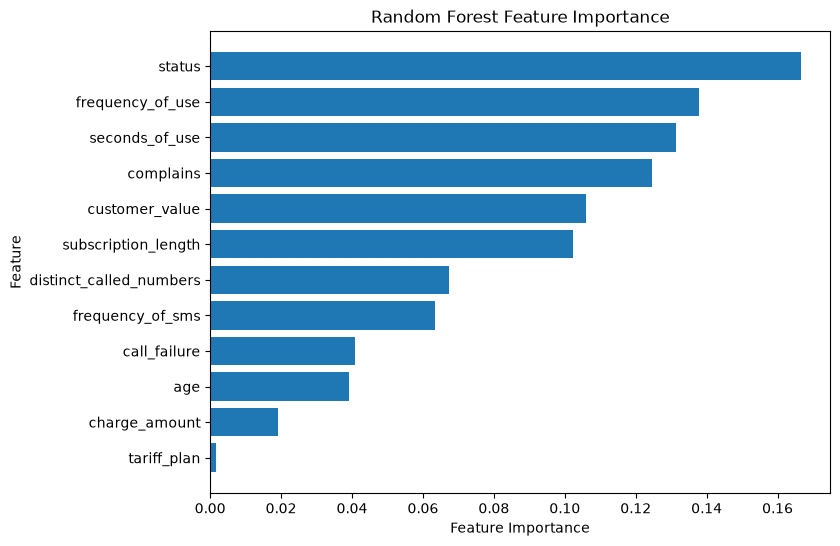

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [98]:
y_test_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [99]:
from sklearn.metrics import roc_auc_score

rf_roc_auc = roc_auc_score(y_test, y_test_prob_rf)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.9853240502958017


In [100]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_rf)

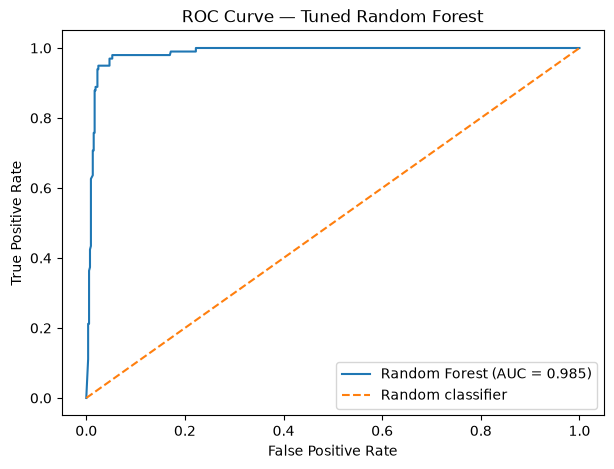

In [101]:
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {rf_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned Random Forest")
plt.legend()

plt.show()


In [102]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob_rf
)

average_precision = average_precision_score(
    y_test,
    y_test_prob_rf
)

print("Average Precision:", average_precision)

Average Precision: 0.8857842886658163


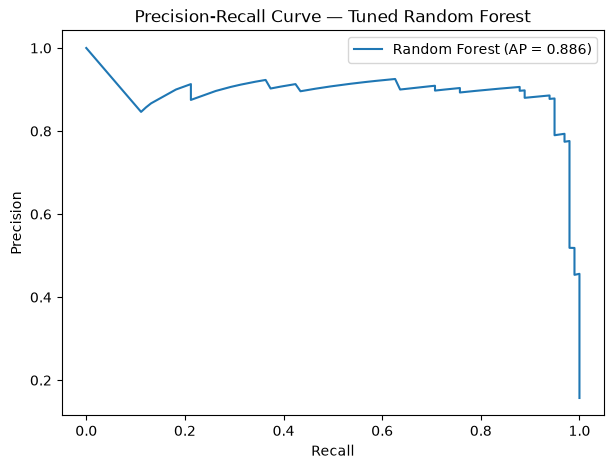

In [103]:
plt.figure(figsize=(7, 5))

plt.plot(
    recall_vals,
    precision_vals,
    label=f"Random Forest (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Tuned Random Forest")
plt.legend()

plt.show()

## 6. Final Model Evaluation

The tuned Random Forest classifier was selected as the final model because it
achieved the strongest cross-validation performance among the models evaluated.

### Model Comparison

- Original Logistic Regression: Mean CV F1 ≈ 0.558
- Balanced Logistic Regression: Mean CV F1 ≈ 0.649
- Decision Tree: Mean CV F1 ≈ 0.810
- Tuned Random Forest: Mean CV F1 ≈ 0.882

The tuned Random Forest used:

- `n_estimators = 300`
- `max_depth = None`
- `min_samples_leaf = 1`
- `max_features = "sqrt"`

### Held-Out Test Performance

On the final test set, the tuned Random Forest achieved:

- Accuracy: approximately 0.97
- Churn Precision: 0.88
- Churn Recall: 0.95
- Churn F1-score: 0.91
- ROC-AUC: approximately 0.985
- Average Precision: approximately 0.886

The confusion matrix showed:

- 518 correctly identified non-churn customers
- 94 correctly identified churn customers
- 13 false-positive churn alerts
- 5 missed churn customers

The model therefore demonstrated strong ability to identify churners while
maintaining relatively few false-positive predictions.

## 8. Limitations

Several limitations should be considered when interpreting the modelling results.

- The dataset contains only 3,150 customers, so performance should be validated
  on larger datasets before operational deployment.
- The data represents an historical Iranian telecom dataset and may not directly
  reflect customer behaviour in other markets, periods, or telecom companies.
- Several usage variables are strongly correlated, including `seconds_of_use`
  and `frequency_of_use`, meaning their individual predictive contributions
  should not be interpreted independently.
- `customer_value` is a calculated dataset variable whose complete derivation
  is not documented in the available dataset description.
- Random Forest impurity-based feature importance measures predictive
  contribution within the model and should not be interpreted as evidence
  of causation.
- Model performance should be monitored over time because customer behaviour
  and churn patterns may change after deployment.

Before real-world use, the model should be validated using current operational
data from the target telecom environment.

## 9. Conclusion

The analysis demonstrates that telecom customer churn can be predicted with
strong performance using customer characteristics and usage behaviour.

Among the evaluated approaches, the tuned Random Forest produced the strongest
cross-validation and held-out test performance. The model achieved high recall
for the churn class while maintaining strong precision, suggesting that it could
provide useful support for identifying customers at elevated churn risk.

The project also demonstrates the importance of evaluating imbalanced
classification problems using class-specific metrics such as precision, recall,
F1-score, ROC-AUC, and Average Precision rather than relying solely on overall
accuracy.